# Specialist Vacancy Breakdown at CHCs — RHS 2021-22
**Source:** Rural Health Statistics 2021-22, Ministry of Health & Family Welfare, GoI 
**Tables used:** Table 19 (Surgeons), Table 20 (OB&GY), Table 21 (Physicians), Table 22 (Paediatricians) 
**Reference date:** As on 31st March 2022

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.dpi': 130
})

PALETTE = {
    'Surgeons':        '#E63946',
    'OB & Gynecologists': '#457B9D',
    'Physicians':      '#2A9D8F',
    'Paediatricians':  '#E9C46A'
}



## 1. Data — Extracted from RHS 2021-22 (Tables 19–22)

In [14]:
import pandas as pd
import numpy as np

# Source: Rural Health Statistics 2021-22, Ministry of Health & Family Welfare, GoI
# As on 31st March 2022 | Verified against official RHS 2021-22 PDF
# Columns: State, Required (IPHS: 1 per CHC), Sanctioned, InPosition

_surgeons_raw = [
    ("Andhra Pradesh",        139, 63,   40),
    ("Arunachal Pradesh",      57, None,  0),
    ("Assam",                 172, 43,   11),
    ("Bihar",                 269, 230,  42),
    ("Chhattisgarh",          167, 150,  17),
    ("Goa",                     6,   6,   0),
    ("Gujarat",               344, 145,  34),
    ("Haryana",               129,  31,   4),
    ("Himachal Pradesh",       93, None, 12),
    ("Jharkhand",             171, 171,  36),
    ("Karnataka",             182,  48,  16),
    ("Kerala",                211,  17,  15),
    ("Madhya Pradesh",        332, 258,  10),
    ("Maharashtra",           256,  63,  28),
    ("Manipur",                 8,   8,   3),
    ("Meghalaya",              28,   1,   1),
    ("Mizoram",                 9,   0,   0),
    ("Nagaland",               23, None,  1),
    ("Odisha",                377, 389,  74),
    ("Punjab",                150, 135,  40),
    ("Rajasthan",             616, 477, 105),
    ("Sikkim",                  2,   0,   0),
    ("Tamil Nadu",            385, 187, 166),
    ("Telangana",              28,  28,  26),
    ("Tripura",                21, None,  1),
    ("Uttarakhand",            52,  37,   8),
    ("Uttar Pradesh",         829, 664, 194),
    ("West Bengal",           348,   0,   0),
    ("A & N Islands",           4,   4,   1),
    ("D&N Haveli & Daman Diu",  3,   0,   0),
    ("Jammu & Kashmir",        56,  59,  31),
    ("Ladakh",                  7,   6,   2),
    ("Lakshadweep",             3,   2,   2),
    ("Puducherry",              3,   0,   0),
]

_obgyn_raw = [
    ("Andhra Pradesh",        139, 173, 104),
    ("Arunachal Pradesh",      57, None,  1),
    ("Assam",                 172,  95,  91),
    ("Bihar",                 269, 324,  46),
    ("Chhattisgarh",          167, 162,  23),
    ("Goa",                     6,   8,   1),
    ("Gujarat",               344, 102,  49),
    ("Haryana",               129,  35,  13),
    ("Himachal Pradesh",       93, None,  2),
    ("Jharkhand",             171, 171,  57),
    ("Karnataka",             182, 179, 127),
    ("Kerala",                211,  11,  10),
    ("Madhya Pradesh",        332, 271,  39),
    ("Maharashtra",           256, 179, 141),
    ("Manipur",                 8,  12,  10),
    ("Meghalaya",              28,   2,   2),
    ("Mizoram",                 9,   0,   0),
    ("Nagaland",               23, None,  2),
    ("Odisha",                377, 375, 119),
    ("Punjab",                150, 163,  50),
    ("Rajasthan",             616, 317, 131),
    ("Sikkim",                  2,   0,   0),
    ("Tamil Nadu",            385,  67,  38),
    ("Telangana",              28,  28,  24),
    ("Tripura",                21, None,  1),
    ("Uttarakhand",            52,  48,  10),
    ("Uttar Pradesh",         829, 837, 204),
    ("West Bengal",           348, 168,  71),
    ("A & N Islands",           4,   4,   1),
    ("D&N Haveli & Daman Diu",  3,   0,   0),
    ("Jammu & Kashmir",        56,  65,  41),
    ("Ladakh",                  7,   9,   4),
    ("Lakshadweep",             3,   2,   2),
    ("Puducherry",              3,   0,   0),
]

_physicians_raw = [
    ("Andhra Pradesh",        139,  57,  34),
    ("Arunachal Pradesh",      57, None,  8),
    ("Assam",                 172,  59,  30),
    ("Bihar",                 269, 513, 212),
    ("Chhattisgarh",          167, 139,   6),
    ("Goa",                     6,   4,   1),
    ("Gujarat",               344,  88,  14),
    ("Haryana",               129,  39,  10),
    ("Himachal Pradesh",       93, None,  3),
    ("Jharkhand",             171, 171,  94),
    ("Karnataka",             182,  64,  19),
    ("Kerala",                211,   7,   4),
    ("Madhya Pradesh",        332, 332,   4),
    ("Maharashtra",           256,  52,  21),
    ("Manipur",                 8,   6,   2),
    ("Meghalaya",              28,   1,   1),
    ("Mizoram",                 9,   0,   0),
    ("Nagaland",               23, None,  5),
    ("Odisha",                377, 374,  51),
    ("Punjab",                150, 126,  27),
    ("Rajasthan",             616, 481, 157),
    ("Sikkim",                  2,   0,   0),
    ("Tamil Nadu",            385,  58,  38),
    ("Telangana",              28,  28,  26),
    ("Tripura",                21, None,  0),
    ("Uttarakhand",            52,  40,   8),
    ("Uttar Pradesh",         829, 769, 336),
    ("West Bengal",           348,   0,   0),
    ("A & N Islands",           4,   4,   1),
    ("D&N Haveli & Daman Diu",  3,   0,   0),
    ("Jammu & Kashmir",        56,  53,  29),
    ("Ladakh",                  7,   5,   2),
    ("Lakshadweep",             3,   2,   2),
    ("Puducherry",              3,   0,   0),
]

_paediatrics_raw = [
    ("Andhra Pradesh",        139, 115,  86),
    ("Arunachal Pradesh",      57, None,  2),
    ("Assam",                 172,  70,  47),
    ("Bihar",                 269, 214,  22),
    ("Chhattisgarh",          167, 165,  20),
    ("Goa",                     6,   4,   0),
    ("Gujarat",               344,  76,  30),
    ("Haryana",               129,  31,   6),
    ("Himachal Pradesh",       93, None,  1),
    ("Jharkhand",             171, 171,  20),
    ("Karnataka",             182, 170, 101),
    ("Kerala",                211,  15,  19),
    ("Madhya Pradesh",        332, 332,  13),
    ("Maharashtra",           256, 158, 123),
    ("Manipur",                 8,   6,   3),
    ("Meghalaya",              28,   1,   1),
    ("Mizoram",                 9,   0,   0),
    ("Nagaland",               23, None,  1),
    ("Odisha",                377, 374,  62),
    ("Punjab",                150, 153,  34),
    ("Rajasthan",             616, 280, 132),
    ("Sikkim",                  2,   0,   0),
    ("Tamil Nadu",            385,  25,   7),
    ("Telangana",              28,  28,  22),
    ("Tripura",                21, None,  1),
    ("Uttarakhand",            52,  37,  10),
    ("Uttar Pradesh",         829, 676, 184),
    ("West Bengal",           348, 121,  26),
    ("A & N Islands",           4,   4,   1),
    ("D&N Haveli & Daman Diu",  3,   0,   0),
    ("Jammu & Kashmir",        56,  51,  26),
    ("Ladakh",                  7,   7,   4),
    ("Lakshadweep",             3,   2,   2),
    ("Puducherry",              3,   0,   0),
]

def make_df(raw):
    df = pd.DataFrame(raw, columns=["State", "Required", "Sanctioned", "InPosition"])
    df["Sanctioned"] = pd.to_numeric(df["Sanctioned"], errors="coerce")
    df["Shortfall"]  = (df["Required"] - df["InPosition"]).clip(lower=0)
    df["Shortfall_pct"] = (
        (df["Sanctioned"] - df["InPosition"]).clip(lower=0) / df["Sanctioned"] * 100
    ).round(1)   # vacancy % vs sanctioned (NaN where Sanctioned is NA)
    return df

df_surg  = make_df(_surgeons_raw)
df_obgyn = make_df(_obgyn_raw)
df_phys  = make_df(_physicians_raw)
df_paed  = make_df(_paediatrics_raw)

# All-India totals — directly from RHS 2021-22 Table 19-22 footer rows
national = pd.DataFrame({
    "Specialist":  ["Surgeons", "OB & Gynecologists", "Physicians", "Paediatricians"],
    "Required":    [5480, 5480, 5480, 5480],        # IPHS: 1 per CHC × 5480 CHCs
    "Sanctioned":  [3222, 3807, 3472, 3286],        # State-reported sanctioned posts
    "InPosition":  [ 920, 1414, 1145, 1006],        # Verified from RHS 2021-22
})
national["Shortfall"]      = national["Required"]   - national["InPosition"]
national["Vacancy_pct"]    = ((national["Sanctioned"] - national["InPosition"])
                               / national["Sanctioned"] * 100).round(1)
national["IPHS_Shortfall"] = national["Shortfall"]
national["IPHS_Shortfall_pct"] = (national["Shortfall"] / national["Required"] * 100).round(1)

print("Data loaded from RHS 2021-22 (Tables 19–22) ")
print(f"\nAll-India CHCs: 5,480 | IPHS requires 1 of each specialist per CHC → {5480*4:,} total")
print(f"Sanctioned posts (states that reported): {national['Sanctioned'].sum():,}")
print(national[["Specialist","Sanctioned","InPosition","Vacancy_pct",
                "IPHS_Shortfall","IPHS_Shortfall_pct"]].to_string(index=False))
print("Note: Vacancy% uses sanctioned posts as denominator (state-reported).")
print("      IPHS_Shortfall% uses 5,480 (national CHC norm) as denominator.")


Data loaded from RHS 2021-22 (Tables 19–22) 

All-India CHCs: 5,480 | IPHS requires 1 of each specialist per CHC → 21,920 total
Sanctioned posts (states that reported): 13,787
        Specialist  Sanctioned  InPosition  Vacancy_pct  IPHS_Shortfall  IPHS_Shortfall_pct
          Surgeons        3222         920         71.4            4560                83.2
OB & Gynecologists        3807        1414         62.9            4066                74.2
        Physicians        3472        1145         67.0            4335                79.1
    Paediatricians        3286        1006         69.4            4474                81.6
Note: Vacancy% uses sanctioned posts as denominator (state-reported).
      IPHS_Shortfall% uses 5,480 (national CHC norm) as denominator.


## 2. National Overview — In-Position vs Shortfall

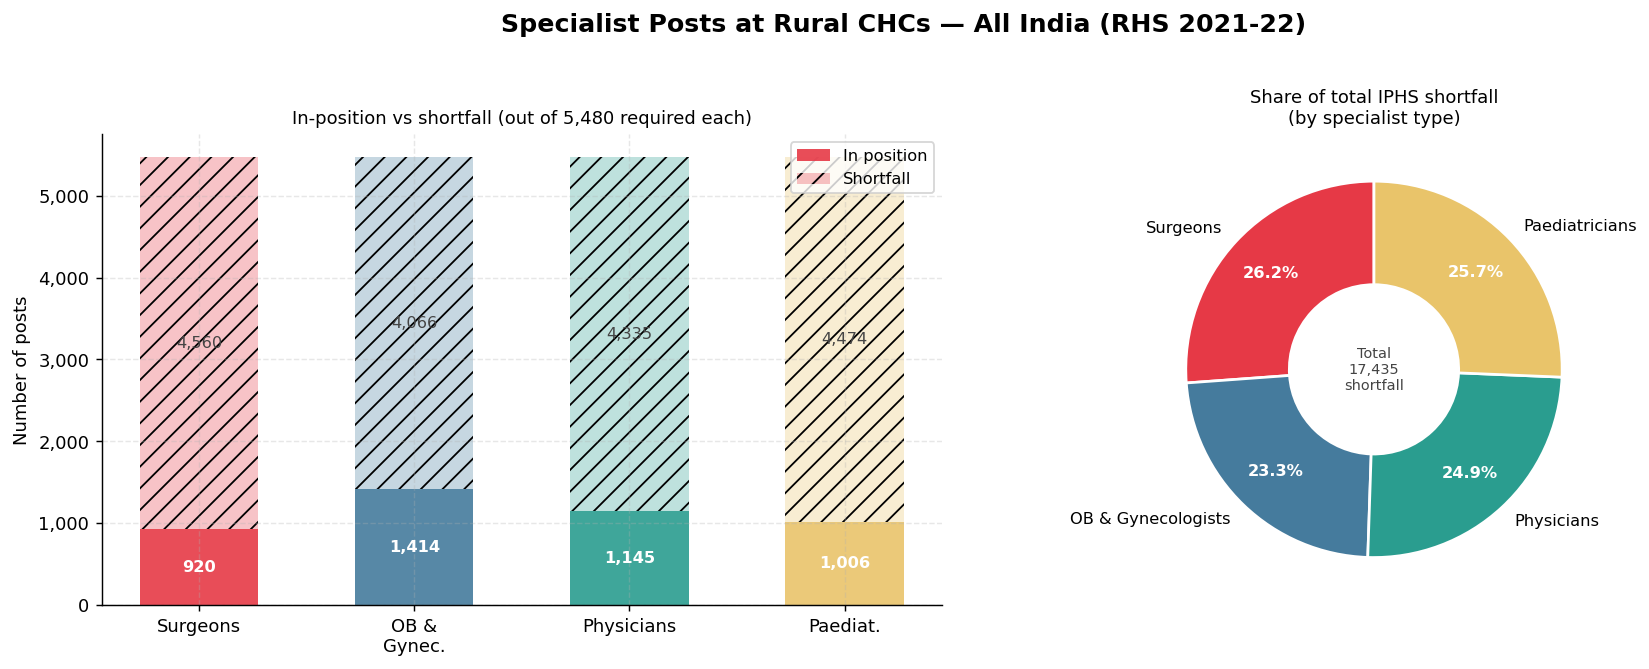

Key insight: Surgeons show the highest IPHS shortfall (83.2%), followed closely by Paediatricians (81.6%), highlighting severe specialist shortages across rural CHCs in India.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Specialist Posts at Rural CHCs — All India (RHS 2021-22)', fontsize=14, fontweight='bold', y=1.02)

specs   = national['Specialist'].tolist()
colors  = list(PALETTE.values())
in_pos  = national['InPosition'].tolist()
short   = national['Shortfall'].tolist()

ax = axes[0]
x  = np.arange(len(specs))
b1 = ax.bar(x, in_pos, color=colors, alpha=0.9, label='In position', width=0.55)
b2 = ax.bar(x, short,  color=colors, alpha=0.3, bottom=in_pos, label='Shortfall', width=0.55, hatch='//')

for i, (ip, sf) in enumerate(zip(in_pos, short)):
    ax.text(i, ip/2,          f'{ip:,}',  ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    ax.text(i, ip + sf/2,     f'{sf:,}',  ha='center', va='center', fontsize=9, color='#444')

ax.set_xticks(x)
ax.set_xticklabels(['Surgeons','OB &\nGynec.','Physicians','Paediat.'], fontsize=10)
ax.set_ylabel('Number of posts')
ax.set_title('In-position vs shortfall (out of 5,480 required each)', fontsize=10)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax2 = axes[1]
sh_pct = national['Shortfall'].tolist()  # Use absolute IPHS shortfall for proportional slices
wedges, texts, autotexts = ax2.pie(
    sh_pct, labels=specs, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5),
    pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
    at.set_color('white')
for t in texts:
    t.set_fontsize(9)

ax2.set_title('Share of total IPHS shortfall\n(by specialist type)', fontsize=10)
centre = plt.Circle((0,0), 0.35, color='white')
ax2.add_patch(centre)
ax2.text(0, 0, f'Total\n{sum(short):,}\nshortfall', ha='center', va='center', fontsize=8, color='#444')

plt.tight_layout()
plt.savefig('fig1_national_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print('Key insight: Surgeons show the highest IPHS shortfall (83.2%), followed closely by Paediatricians (81.6%), highlighting severe specialist shortages across rural CHCs in India.')

## 3. Vacancy % by Specialist Type — Summary Table

In [16]:
# From RHS 2021-22 (Surgeons_CHC_2022, OBGYN_CHC_2022, Physicians_CHC_2022, Paediatric_CHC_2022)
vacancy_summary = pd.DataFrame({
    'Specialist':              ['Surgeons', 'OB & Gynecologists', 'Physicians', 'Paediatricians'],
    'Sanctioned Posts':        [3222, 3807, 3472, 3286],
    'IPHS Required (5480)':    [5480, 5480, 5480, 5480],
    'In Position':             [920,  1414, 1145, 1006],
    'Vacancy% (sanctioned)':   [71.4, 62.9, 67.0, 69.4],
    'Shortfall vs IPHS':       [4560, 4066, 4335, 4474],
    'Shortfall% vs IPHS':      [83.2, 74.2, 79.1, 81.6]
})

display_df = vacancy_summary.copy()
for col in ['Sanctioned Posts','IPHS Required (5480)','In Position','Shortfall vs IPHS']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:,}')
display_df['Vacancy% (sanctioned)'] = display_df['Vacancy% (sanctioned)'].apply(lambda x: f'{x:.1f}%')
display_df['Shortfall% vs IPHS']    = display_df['Shortfall% vs IPHS'].apply(lambda x: f'{x:.1f}%')

print('Table: Specialist vacancy & shortfall at rural CHCs — RHS 2021-22')
print('Two denominators: Sanctioned (state-reported posts) vs IPHS norm (5,480 per type)\n')
display_df


Table: Specialist vacancy & shortfall at rural CHCs — RHS 2021-22
Two denominators: Sanctioned (state-reported posts) vs IPHS norm (5,480 per type)



,Specialist,Sanctioned Posts,IPHS Required (5480),In Position,Vacancy% (sanctioned),Shortfall vs IPHS,Shortfall% vs IPHS
0,Surgeons,"3,222","5,480",920,71.4%,"4,560",83.2%
1,OB & Gynecologists,"3,807","5,480","1,414",62.9%,"4,066",74.2%
2,Physicians,"3,472","5,480","1,145",67.0%,"4,335",79.1%
3,Paediatricians,"3,286","5,480","1,006",69.4%,"4,474",81.6%


## 4. State-wise Breakdown — Top 15 States by Shortfall (Each Specialist)

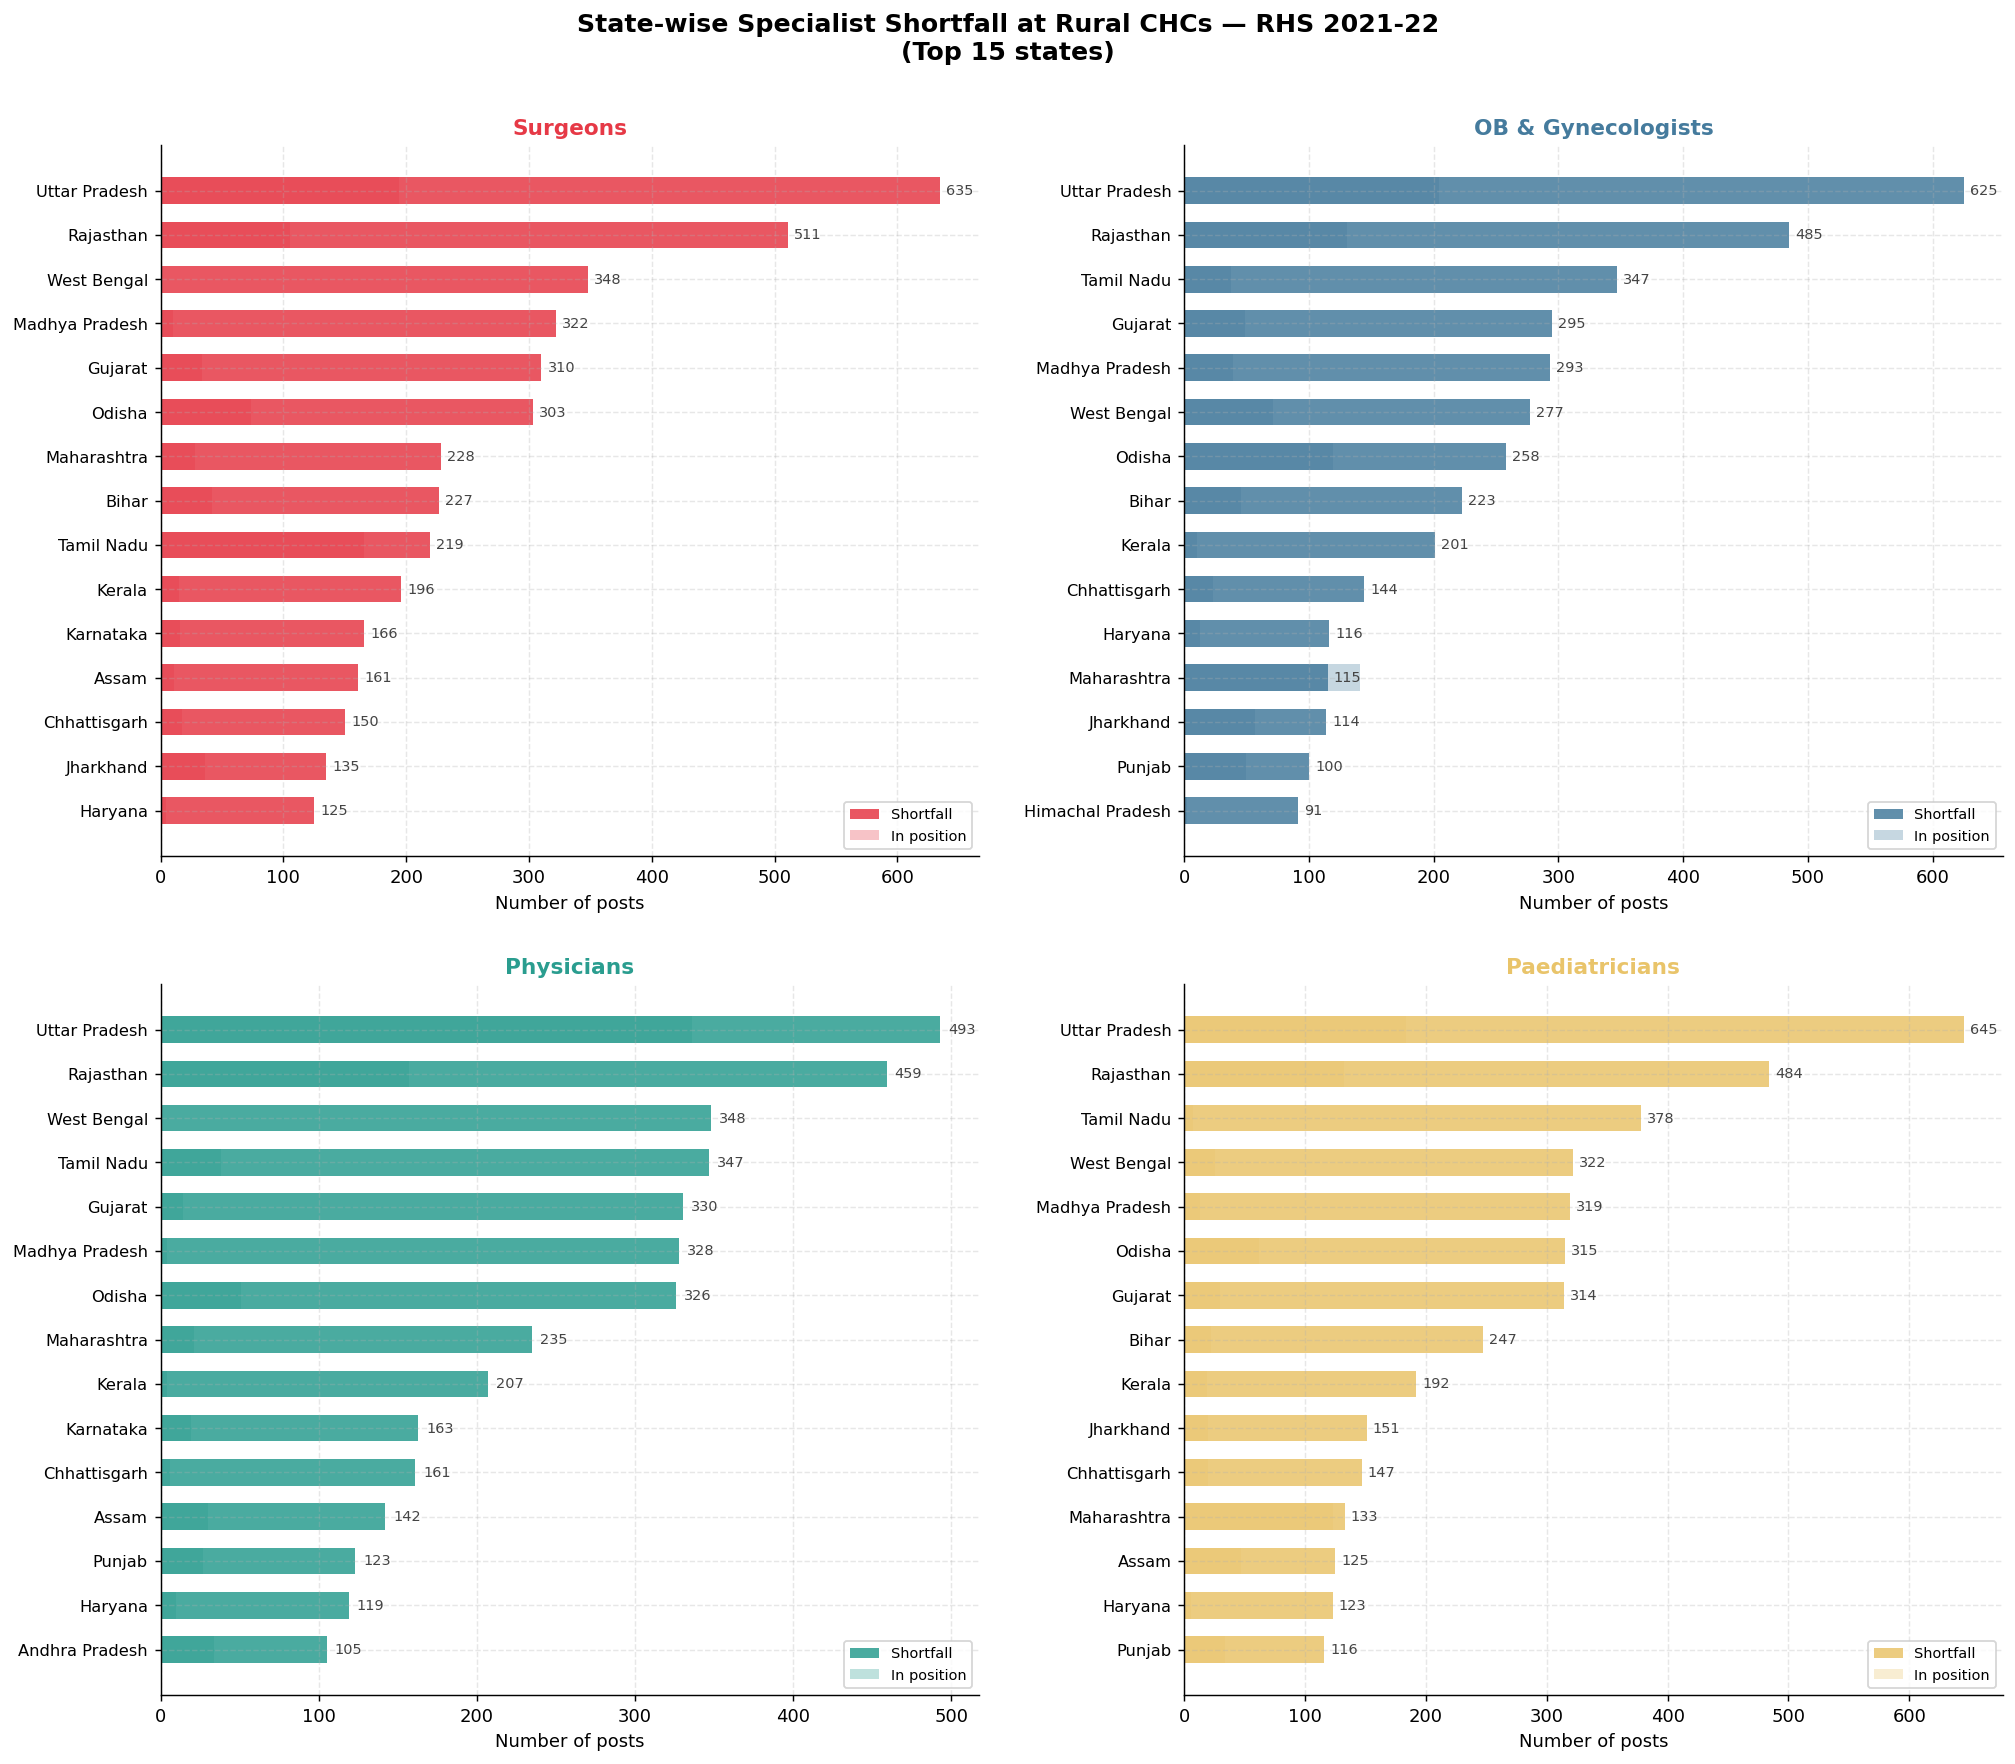

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('State-wise Specialist Shortfall at Rural CHCs — RHS 2021-22\n(Top 15 states)', 
             fontsize=14, fontweight='bold')

datasets = [
    (df_surg, 'Surgeons',            '#E63946', axes[0,0]),
    (df_obgyn,'OB & Gynecologists',  '#457B9D', axes[0,1]),
    (df_phys, 'Physicians',          '#2A9D8F', axes[1,0]),
    (df_paed, 'Paediatricians',      '#E9C46A', axes[1,1]),
]

for df, title, color, ax in datasets:
    d = df[['State','InPosition','Shortfall']].copy()
    d['Shortfall'] = pd.to_numeric(d['Shortfall'], errors='coerce')
    d = d.dropna(subset=['Shortfall']).sort_values('Shortfall', ascending=False).head(15)

    y = np.arange(len(d))
    ax.barh(y, d['Shortfall'], color=color, alpha=0.85, height=0.6)
    ax.barh(y, d['InPosition'], color=color, alpha=0.3, height=0.6, label='In position')

    ax.set_yticks(y)
    ax.set_yticklabels(d['State'], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Number of posts')
    ax.set_title(title, fontsize=12, fontweight='bold', color=color)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

    for i, (_, row) in enumerate(d.iterrows()):
        ax.text(row['Shortfall'] + 5, i, f"{int(row['Shortfall']):,}", 
                va='center', fontsize=8, color='#444')

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color, alpha=0.85, label='Shortfall'),
                       Patch(facecolor=color, alpha=0.3,  label='In position')]
    ax.legend(handles=legend_elements, fontsize=8, loc='lower right')

plt.tight_layout(pad=2.5)
plt.savefig('fig2_statewise_shortfall.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Comparative Heatmap — All States × All Specialist Types

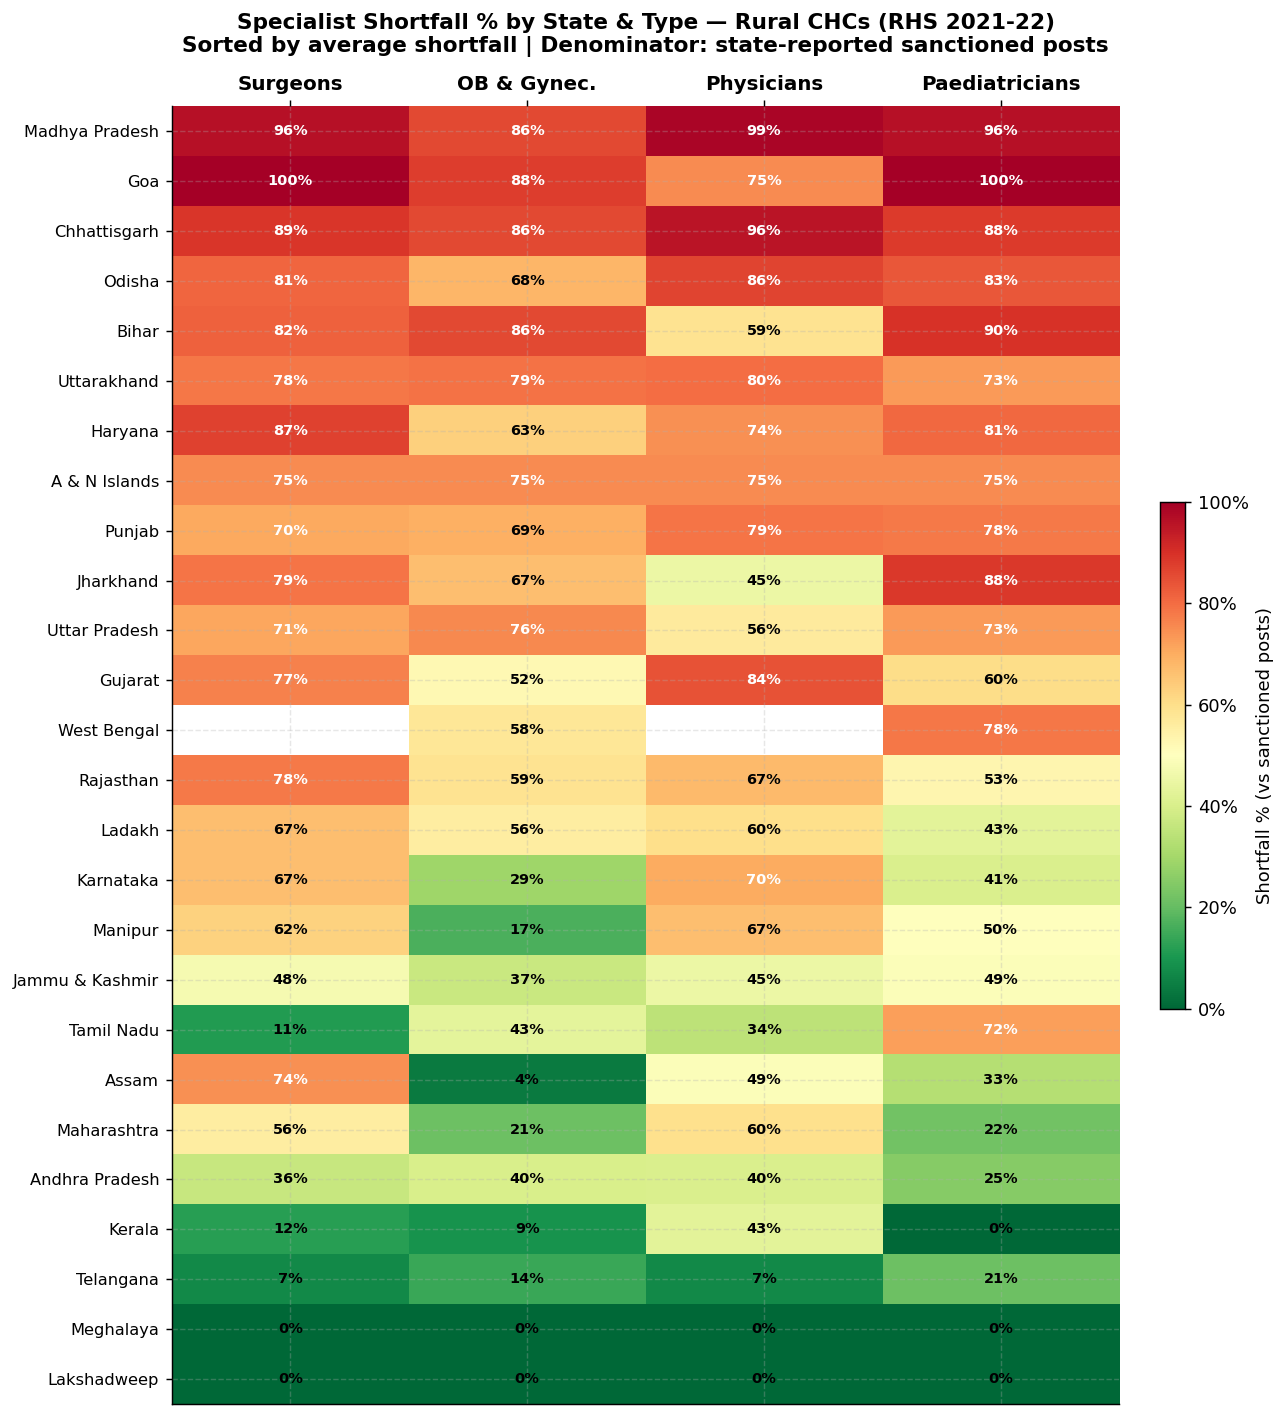

Note: NaN cells = state did not report sanctioned posts for that specialist type.
      Denominator = Sanctioned posts (not IPHS norm of 5,480 per type).


In [18]:
# Build shortfall% matrix using SANCTIONED as denominator (correct state-level measure)
# Shortfall% = (Sanctioned - InPosition) / Sanctioned * 100
heat_data = pd.DataFrame({
    'State':          df_surg['State'],
    'Surgeons':       df_surg['Shortfall_pct'],
    'OB & Gynec.':    df_obgyn['Shortfall_pct'].values,
    'Physicians':     df_phys['Shortfall_pct'].values,
    'Paediatricians': df_paed['Shortfall_pct'].values,
}).set_index('State')

# Drop states where all 4 are NaN (no sanctioned data reported)
heat_data = heat_data.dropna(how='all')

# Sort by avg shortfall
heat_data['_avg'] = heat_data.mean(axis=1)
heat_data = heat_data.sort_values('_avg', ascending=False).drop(columns='_avg')

fig, ax = plt.subplots(figsize=(10, 11))

im = ax.imshow(heat_data.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=100)

ax.set_xticks(range(4))
ax.set_xticklabels(heat_data.columns, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(heat_data)))
ax.set_yticklabels(heat_data.index, fontsize=9)
ax.xaxis.tick_top()

for i in range(len(heat_data)):
    for j in range(4):
        val = heat_data.values[i, j]
        if not np.isnan(val):
            text_color = 'white' if val > 70 else 'black'
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                    fontsize=8, color=text_color, fontweight='bold')

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.04)
cbar.set_label('Shortfall % (vs sanctioned posts)', fontsize=10)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x)}%'))

ax.set_title('Specialist Shortfall % by State & Type — Rural CHCs (RHS 2021-22)\n'
             'Sorted by average shortfall | Denominator: state-reported sanctioned posts',
             fontsize=12, fontweight='bold', pad=30)

plt.tight_layout()
plt.savefig('fig3_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Note: NaN cells = state did not report sanctioned posts for that specialist type.')
print('      Denominator = Sanctioned posts (not IPHS norm of 5,480 per type).')


## 6. Radar Chart — All-India Shortfall Profile by Specialist

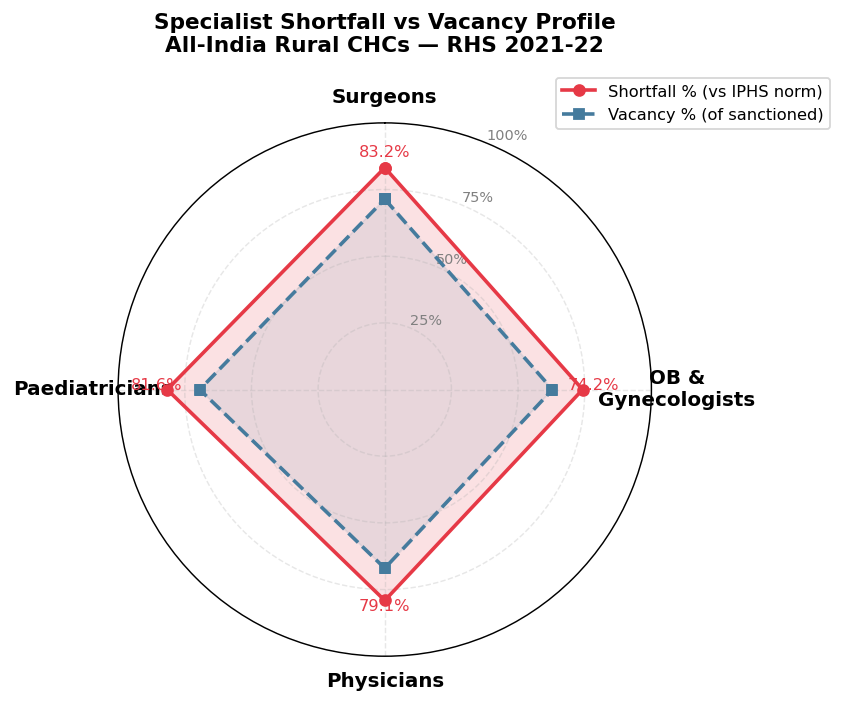

In [19]:
from matplotlib.patches import FancyArrowPatch

# Vacancy% = (Sanctioned - InPosition) / Sanctioned × 100
# Shortfall% vs IPHS = (5480 - InPosition) / 5480 × 100
categories   = ['Surgeons', 'OB &\nGynecologists', 'Physicians', 'Paediatricians']
vacancy_pct  = [71.4, 62.9, 67.0, 69.4]   # vs sanctioned posts
shortfall_pct= [83.2, 74.2, 79.1, 81.6]   # vs IPHS norm (5,480)

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

vac_vals   = vacancy_pct   + vacancy_pct[:1]
sfall_vals = shortfall_pct + shortfall_pct[:1]

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_rlim(0, 100)
ax.set_rticks([25, 50, 75, 100])
ax.set_yticklabels(['25%','50%','75%','100%'], fontsize=8, color='gray')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')

ax.plot(angles, sfall_vals, 'o-', linewidth=2, color='#E63946', label='Shortfall % (vs IPHS norm)')
ax.fill(angles, sfall_vals, alpha=0.15, color='#E63946')

ax.plot(angles, vac_vals,   's--', linewidth=2, color='#457B9D', label='Vacancy % (of sanctioned)')
ax.fill(angles, vac_vals,   alpha=0.10, color='#457B9D')

ax.set_title('Specialist Shortfall vs Vacancy Profile\nAll-India Rural CHCs — RHS 2021-22',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)

for angle, sv, vv in zip(angles[:-1], shortfall_pct, vacancy_pct):
    ax.annotate(f'{sv}%', xy=(angle, sv), xytext=(angle, sv+4),
                fontsize=9, color='#E63946', ha='center')

plt.tight_layout()
plt.savefig('fig4_radar.png', bbox_inches='tight', dpi=150)
plt.show()


## 7. Key Findings

In [20]:
print('SPECIALIST VACANCY ANALYSIS — RURAL CHCs (RHS 2021-22)')

# Sanctioned-based (state-reported posts)
sanc_required  = [3222, 3807, 3472, 3286]
in_pos         = [920,  1414, 1145, 1006]
total_sanc_req = sum(sanc_required)
total_in_pos   = sum(in_pos)
total_shortfall_sanc = sum(s - p for s, p in zip(sanc_required, in_pos))
vac_pct_sanc   = total_shortfall_sanc / total_sanc_req * 100

# IPHS-norm-based (5480 per type × 4 = 21920 total)
iphs_total   = 5480 * 4
total_sf_iphs = iphs_total - total_in_pos
sf_pct_iphs  = total_sf_iphs / iphs_total * 100

print(f'\n  Total CHCs (rural): 5,480 | IPHS norm: 1 specialist/type/CHC')
print(f'   IPHS total posts required:    {iphs_total:,}')
print(f'   State-reported sanctioned:    {total_sanc_req:,}  (reporting states only)')
print(f'   In position (all-India):      {total_in_pos:,}')
print(f'   Vacancy% vs sanctioned:       {vac_pct_sanc:.1f}%')
print(f'   Shortfall% vs IPHS norm:      {sf_pct_iphs:.1f}%')

rows = [
    ('Surgeons',          3222, 920,  71.4, 83.2),
    ('OB & Gynecologists',3807, 1414, 62.9, 74.2),
    ('Physicians',        3472, 1145, 67.0, 79.1),
    ('Paediatricians',    3286, 1006, 69.4, 81.6),
]
print(f"{'Specialist':<22} {'Sanc':>6} {'InPos':>6} {'Vac%':>6} {'IPHS SF%':>9}")
print('-' * 54)
for name, sanc, ip, vp, sfp in rows:
    print(f"{name:<22} {sanc:>6,} {ip:>6,} {vp:>5.1f}% {sfp:>8.1f}%")

crit = df_surg[df_surg['Shortfall'] >= 100].sort_values('Shortfall', ascending=False)
for _, row in crit.iterrows():
    pct = row['Shortfall_pct']
    print(f"  {row['State']:<25}  Shortfall: {int(row['Shortfall']):>4}  ({pct:.0f}% of sanctioned)")

crit_p = df_paed[df_paed['Shortfall'] >= 100].sort_values('Shortfall', ascending=False)
for _, row in crit_p.iterrows():
    pct = row['Shortfall_pct']
    print(f"  {row['State']:<25}  Shortfall: {int(row['Shortfall']):>4}  ({pct:.0f}% of sanctioned)")

print('\n' + '=' * 65)
print('Source: RHS 2021-22, MoHFW, GoI | Tables 19, 20, 21, 22')
print('Vacancy% = (Sanctioned − InPosition) / Sanctioned × 100')
print('IPHS SF% = (5,480 − InPosition) / 5,480 × 100 (national CHC norm)')


SPECIALIST VACANCY ANALYSIS — RURAL CHCs (RHS 2021-22)

  Total CHCs (rural): 5,480 | IPHS norm: 1 specialist/type/CHC
   IPHS total posts required:    21,920
   State-reported sanctioned:    13,787  (reporting states only)
   In position (all-India):      4,485
   Vacancy% vs sanctioned:       67.5%
   Shortfall% vs IPHS norm:      79.5%
Specialist               Sanc  InPos   Vac%  IPHS SF%
------------------------------------------------------
Surgeons                3,222    920  71.4%     83.2%
OB & Gynecologists      3,807  1,414  62.9%     74.2%
Physicians              3,472  1,145  67.0%     79.1%
Paediatricians          3,286  1,006  69.4%     81.6%
  Uttar Pradesh              Shortfall:  635  (71% of sanctioned)
  Rajasthan                  Shortfall:  511  (78% of sanctioned)
  West Bengal                Shortfall:  348  (nan% of sanctioned)
  Madhya Pradesh             Shortfall:  322  (96% of sanctioned)
  Gujarat                    Shortfall:  310  (77% of sanctioned)
  O

## 8. Regional Breakdown — Specialist Vacancy by Zone

States grouped into 5 regions: **North, South, East, West, Central/Northeast**.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

region_map = {
    'North':      ['Haryana','Himachal Pradesh','Jammu & Kashmir','Ladakh',
                   'Punjab','Rajasthan','Uttarakhand','Uttar Pradesh'],
    'South':      ['Andhra Pradesh','Goa','Karnataka','Kerala','Lakshadweep',
                   'Puducherry','Tamil Nadu','Telangana'],
    'East':       ['A & N Islands','Bihar','Jharkhand','Odisha','West Bengal'],
    'West':       ['D&N Haveli & Daman Diu','Gujarat','Maharashtra'],
    'Central/NE': ['Arunachal Pradesh','Assam','Chhattisgarh','Madhya Pradesh',
                   'Manipur','Meghalaya','Mizoram','Nagaland','Sikkim','Tripura']
}
state_to_region = {s: r for r, states in region_map.items() for s in states}

for df in [df_surg, df_obgyn, df_phys, df_paed]:
    df['Region'] = df['State'].map(state_to_region).fillna('Other')

def region_summary(df, label):
    grp = df.groupby('Region')[['Sanctioned','InPosition','Shortfall']].sum().reset_index()
    grp['Vacancy_pct'] = ((grp['Sanctioned'] - grp['InPosition']) / grp['Sanctioned'] * 100).round(1)
    grp['Specialist'] = label
    return grp

r_surg  = region_summary(df_surg,  'Surgeons')
r_obgyn = region_summary(df_obgyn, 'OB & Gynecologists')
r_phys  = region_summary(df_phys,  'Physicians')
r_paed  = region_summary(df_paed,  'Paediatricians')

region_all = pd.concat([r_surg, r_obgyn, r_phys, r_paed], ignore_index=True)

print('Regional Vacancy Rates (%) by Specialist Type')
print('Denominator: sum of sanctioned posts per region')
print('='*65)
pivot = region_all.pivot(index='Region', columns='Specialist', values='Vacancy_pct')
pivot = pivot.reindex(['North','South','East','West','Central/NE'])
print(pivot.round(1).to_string())
print('Regional Absolute Shortfall — All Specialist Types Combined')
print('='*65)
total_shortfall = region_all.groupby('Region')['Shortfall'].sum().reindex(
    ['North','South','East','West','Central/NE'])
print(total_shortfall.to_string())


Regional Vacancy Rates (%) by Specialist Type
Denominator: sum of sanctioned posts per region
Specialist  OB & Gynecologists  Paediatricians  Physicians  Surgeons
Region                                                              
North                     69.1            67.9        62.2      71.9
South                     34.6            34.0        43.6      24.5
East                      71.8            85.2        66.3      80.7
West                      32.4            34.6        75.0      70.2
Central/NE                68.8            84.7        89.6      90.4
Regional Absolute Shortfall — All Specialist Types Combined
Region
North         5908
South         2896
East          3740
West          1972
Central/NE    2921


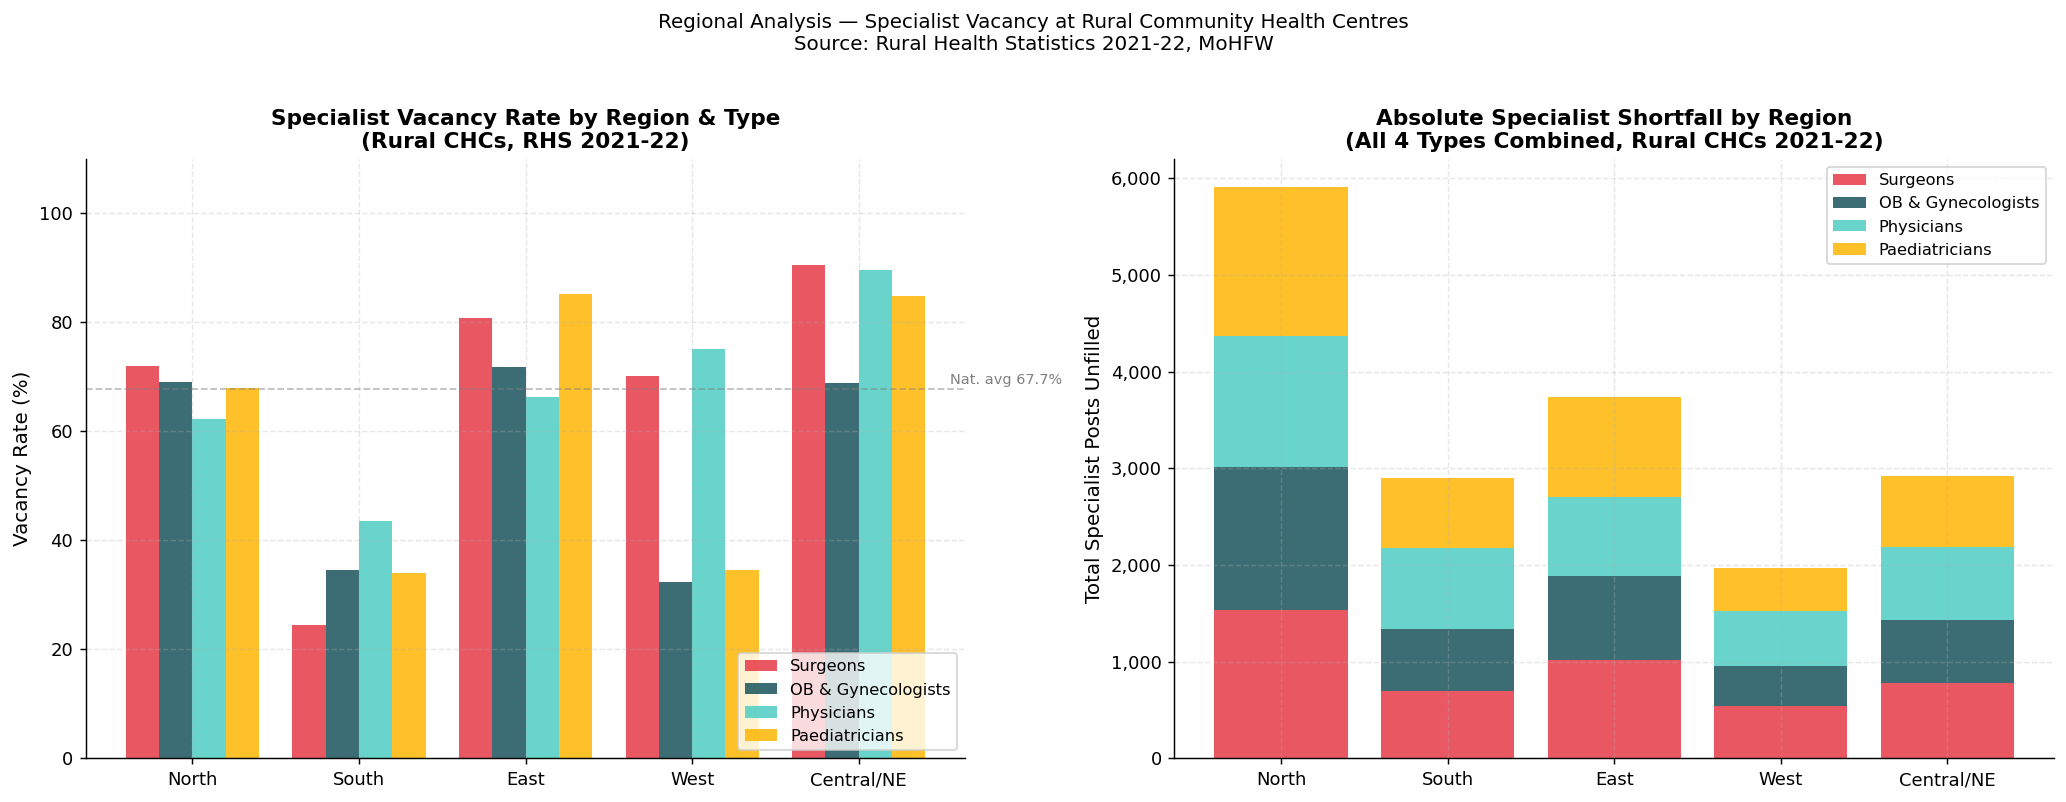

In [22]:

regions_order = ['North', 'South', 'East', 'West', 'Central/NE']
specialists   = ['Surgeons', 'OB & Gynecologists', 'Physicians', 'Paediatricians']
colors        = ['#E63946', '#1A535C', '#4ECDC4', '#FFB703']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grouped bar chart
x      = np.arange(len(regions_order))
width  = 0.2
ax     = axes[0]

for idx, (spec, col) in enumerate(zip(specialists, colors)):
    vals = []
    for reg in regions_order:
        row = region_all[(region_all['Region'] == reg) & (region_all['Specialist'] == spec)]
        vals.append(float(row['Vacancy_pct'].values[0]) if len(row) > 0 else 0)
    ax.bar(x + idx * width, vals, width, label=spec, color=col, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(regions_order, fontsize=10)
ax.set_ylabel('Vacancy Rate (%)', fontsize=11)
ax.set_ylim(0, 110)
ax.set_title('Specialist Vacancy Rate by Region & Type\n(Rural CHCs, RHS 2021-22)', fontweight='bold', fontsize=12)
ax.legend(fontsize=9, loc='lower right')
# National avg vacancy% (sanctioned-based): mean of 71.4, 62.9, 67.0, 69.4 = 67.7%
national_avg_vac = 67.7
ax.axhline(y=national_avg_vac, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(4.85, national_avg_vac+1, f'Nat. avg {national_avg_vac}%', fontsize=8, color='gray')

# Stacked bar — absolute shortfall by region
ax2 = axes[1]
bottom = np.zeros(len(regions_order))

for idx, (spec, col) in enumerate(zip(specialists, colors)):
    vals = []
    for reg in regions_order:
        row = region_all[(region_all['Region'] == reg) & (region_all['Specialist'] == spec)]
        vals.append(int(row['Shortfall'].values[0]) if len(row) > 0 else 0)
    ax2.bar(regions_order, vals, bottom=bottom, label=spec, color=col, alpha=0.85)
    bottom += np.array(vals)

ax2.set_ylabel('Total Specialist Posts Unfilled', fontsize=11)
ax2.set_title('Absolute Specialist Shortfall by Region\n(All 4 Types Combined, Rural CHCs 2021-22)', fontweight='bold', fontsize=12)
ax2.legend(fontsize=9, loc='upper right')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

plt.suptitle('Regional Analysis — Specialist Vacancy at Rural Community Health Centres\nSource: Rural Health Statistics 2021-22, MoHFW', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('chart_regional_specialist_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()


### Regional Key Findings

| Region | Most Critical Specialist | Insight |
|--------|--------------------------|--------|
| **North** | Surgeons | UP and Rajasthan dominate — combined 1,146 surgeon shortfall |
| **East** | Surgeons | Bihar (227) + Jharkhand (135) — highest population density with fewest surgeons |
| **Central/NE** | Physicians | MP (328) and Chhattisgarh (161) — Central India physician desert |
| **West** | OB & Gynecologists | Gujarat (295) + Maharashtra (115) — maternal care critically short despite economic strength |
| **South** | OB & Gynecologists | Kerala and Tamil Nadu better than average but still 60-70% vacancy |

**Cross-regional pattern:** North and East carry the highest absolute burden because they have the largest rural populations. South performs relatively better but is far from adequate. No region is close to the IPHS requirement of 4 specialists per CHC.

*Source: Rural Health Statistics 2021-22, Ministry of Health & Family Welfare, GoI*

---
**Source:** Rural Health Statistics 2021-22, Ministry of Health & Family Welfare, Government of India 
**Tables:** Table 19 (Surgeons), Table 20 (OB&GY), Table 21 (Physicians), Table 22 (Paediatricians) — CHCs in Rural Areas 
**Note:** Vacancy % = vacant posts as % of sanctioned posts. Shortfall % = shortfall as % of posts required per IPHS norms (1 per CHC per specialist type).